# Snippet - Regressão Ridge
A regressão ridge se difere da regressão linear básica por impor uma penalidade no tamanho dos coeficientes. Os coeficientes aqui minimizam uma soma quadrática residual penalizada. Um parâmetro $\alpha >= 0$ controla o tamanho do encolhimento: quanto maior seu valor, maior o encolhimento e portanto os coeficientes se tornam mais robustos contra colinearidades.

A função objetivo é descrita como: $min||Xw-y||^2+ \alpha||w||^2$

A figura abaixo representa o modelo.

<img src="./img/Ridge_plot.png" alt="Plot de exemplo dos coeficientes de acordo com o valor de alpha." style="height:300px;">
</br></br>



In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
# Data
data = {
    "x1": [1, 2, 3, 4, 5],
    "x2": [3, 6, 9, 12, 15],           # Relação linear com x1
    "x3": [2, 5, 1, 7, 4],             # Valores variados
    "x4": [2, 8, 18, 32, 50],          # Relação quadrática crescente
    "x5": [8, 7, 5, 3, 2],             # Decrescente
    "y":  [12, 22, 27, 45, 62]         # Combinação linear + ruído
}

df = pd.DataFrame(data)

In [3]:
# Fit
lg = linear_model.Ridge(alpha=0.5)
lg.fit(df[["x1","x2","x3","x4","x5"]],df["y"])

,alpha,0.5
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [4]:
# Attributes
print(f'Intercept: {lg.intercept_}\nCoeficients:{lg.coef_}')

Intercept: -1.7692891906958366
Coeficients:[0.12851106 0.38553319 0.83299461 1.02837247 1.14487666]


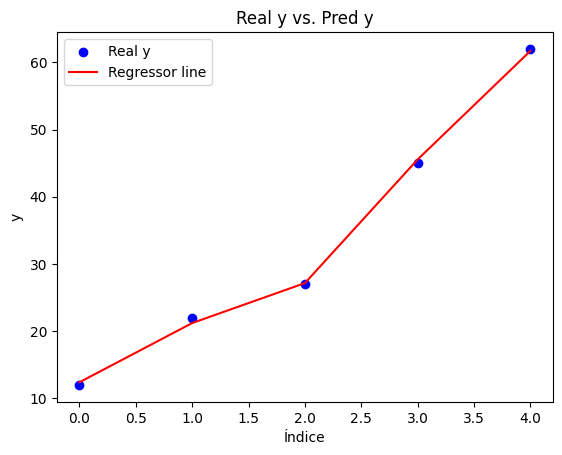

In [5]:
# Prep
X = df[["x1","x2","x3","x4","x5"]]
y = df["y"]
y_pred = lg.intercept_ + np.dot(X, lg.coef_)

# Viz
plt.scatter(range(len(y)), y, color='blue', label='Real y')
plt.plot(range(len(y_pred)), y_pred, color='red', label='Regressor line')
plt.xlabel('Índice')
plt.ylabel('y')
plt.legend()
plt.title('Real y vs. Pred y')
plt.show()